# 3. 人审与校准

## 学习目标
理解固定预算下的分层残差校正和适用条件。

**数据来源：** 原有方法实验使用 `aiv/data.py` 的确定性合成样本；本页后半部读取 `results/final-analysis/` 的真实聚合观察或条件分析。两类结果分别标明范围。

## 运行准备
在项目环境中从干净内核运行全部单元。默认不读取 .env、不调用 API。

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
from aiv.data import synthetic_records

records = synthetic_records(seed=26)
LIVE_API = False  # Explicit opt-in only. Default cells never spend credits.
from aiv.notebook_materials import configure_style, save_figure
configure_style()

## 固定预算分配

In [2]:
from aiv.calibration import allocate_review, residual_mean, agreement

allocation = allocate_review([0.5, 0.3, 0.2], [0.1, 0.3, 0.5], [1, 2, 3], budget=70)
display(
    pd.DataFrame({"stratum": ["low", "medium", "high"], "n": allocation["allocation"]})
)
print("Person-minute cost:", allocation["cost"])

,stratum,n
0,low,11
1,medium,13
2,high,11


Person-minute cost: 70.0


这里的标准差、成本与70分钟预算均为教学设定。实际分配应使用目标复核任务的试标耗时和残差估计。

## 残差校正模拟

,estimate
known truth,0.450000
prediction only,0.561423
residual corrected,0.418793


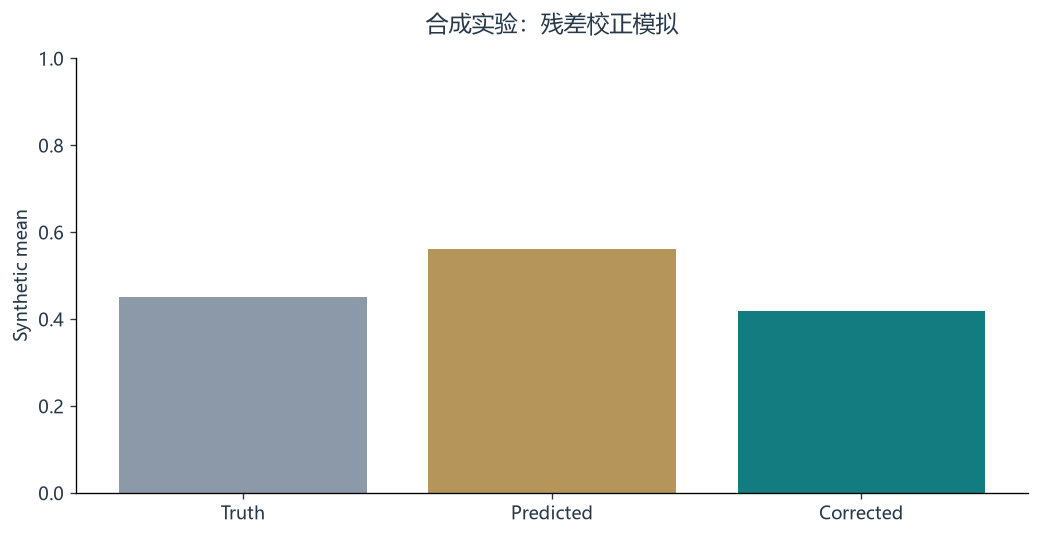

In [3]:
rng = np.random.default_rng(26)
truth = rng.binomial(1, 0.45, 400)
prediction = np.clip(truth * 0.6 + 0.3 + rng.normal(0, 0.15, 400), 0, 1)
idx = rng.choice(400, 50, replace=False)
corrected = residual_mean(prediction, idx, truth[idx])
display(
    pd.DataFrame(
        {"estimate": [truth.mean(), prediction.mean(), corrected["estimate"]]},
        index=["known truth", "prediction only", "residual corrected"],
    )
)
plt.bar(
    ["Truth", "Predicted", "Corrected"],
    [truth.mean(), prediction.mean(), corrected["estimate"]],
    color=["#8b99a9", "#b6955b", "#137c80"],
)
plt.ylim(0, 1)
plt.ylabel("Synthetic mean")
plt.tight_layout()
save_figure(plt.gcf(), 'synthetic-03-01', '合成实验：残差校正模拟', kind='synthetic', sources=['aiv/calibration.py', 'aiv/data.py', 'aiv/analysis.py', 'aiv/metrics.py', 'results/synthetic/residual-coverage-summary.json', 'results/synthetic/residual-coverage-trials.csv'], notebook='03_人审与校准.ipynb')
plt.show()

有限总体简单随机抽样保证残差估计无偏。小样本正态区间只是近似；同学生多条相关记录需要按学生设计抽样或聚类方差。

## 有限总体覆盖率模拟
500 次层内简单随机抽样，人工样本量40。该实验只验证给定合成有限总体的近似区间，不替代真实学生聚类覆盖率检查。

,0
replications,500
population,400
human_sample,40
truth,0.45
prediction_mean,0.561423
bias,-0.00097
coverage,0.946
coverage_monte_carlo_se,0.010108
mean_width,0.148032
scope,fixed synthetic finite population; SRS; not re...


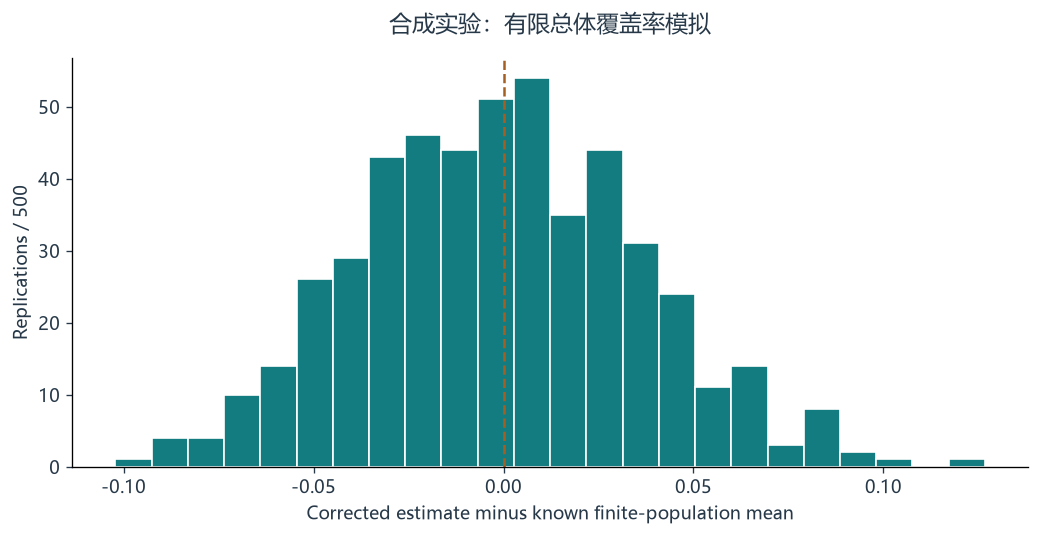

In [4]:
coverage = json.loads(
    (ROOT / "results/synthetic/residual-coverage-summary.json").read_text()
)
display(pd.DataFrame([coverage]).T)
trials = pd.read_csv(ROOT / "results/synthetic/residual-coverage-trials.csv")
plt.hist(trials.error, bins=24, color="#137c80", edgecolor="white")
plt.axvline(0, color="#a65f22", linestyle="--")
plt.xlabel("Corrected estimate minus known finite-population mean")
plt.ylabel("Replications / 500")
plt.tight_layout()
save_figure(plt.gcf(), 'synthetic-03-02', '合成实验：有限总体覆盖率模拟', kind='synthetic', sources=['aiv/calibration.py', 'aiv/data.py', 'aiv/analysis.py', 'aiv/metrics.py', 'results/synthetic/residual-coverage-summary.json', 'results/synthetic/residual-coverage-trials.csv'], notebook='03_人审与校准.ipynb')
plt.show()

## 计算检查

In [5]:
assert allocation["cost"] <= 70
census = residual_mean(prediction, np.arange(400), truth)
assert abs(census["estimate"] - truth.mean()) < 1e-10

## 材料衔接
本页将校准方法的合成实验与同题人工复核记录分列。总体误差校准仍需独立参考标签及相应抽样设计。

## 真实观察：同题人审的耗时与判断
重测与 AI 建议辅助阶段覆盖相同的 8 道题、A/B 两位评审，共 16 对“同题—同角色”提交。
记录耗时包含停顿；题目顺序固定，辅助阶段共享 AI 推荐。以下描述工作流程中的观察变化。
来源：`results/final-analysis/human-role-timing.csv` 与 `summary.json` 的 `human`。

In [6]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import configure_style, save_figure
configure_style()
FINAL_DIR = ROOT / "results" / "final-analysis"
_final_summary_path = FINAL_DIR / "summary.json"
final_summary = json.loads(_final_summary_path.read_text(encoding="utf-8")) if _final_summary_path.is_file() else None

def final_csv(name):
    return pd.read_csv(FINAL_DIR / name) if final_summary is not None else pd.DataFrame()

if final_summary is None:
    display(Markdown("本目录未附真实聚合分析；以下真实结果保持空白，前面的合成实验仍可复算。"))
else:
    display(pd.DataFrame([{
        "分析输入": "results/final-analysis/summary.json",
        "冻结修订": final_summary["source"]["revision"],
        "快照清单 SHA-256": final_summary["source"]["manifest_sha256"],
        "真实回合": final_summary["denominators"]["real_turns"],
        "学生—学期": final_summary["denominators"]["student_terms"],
    }]))

,分析输入,冻结修订,快照清单 SHA-256,真实回合,学生—学期
0,results/final-analysis/summary.json,t3,7e885ceecf12a180349369ed9ddfc962ad71f1ea270f68...,3515,401


round,独立重测（人分钟）,AI辅助（人分钟）
role,,
A,14.46,4.80
B,10.10,14.62


,同题同角色配对,前阶段人分钟,辅助阶段人分钟,耗时减少配对,耗时增加配对
0,16,24.55,19.41,13,3


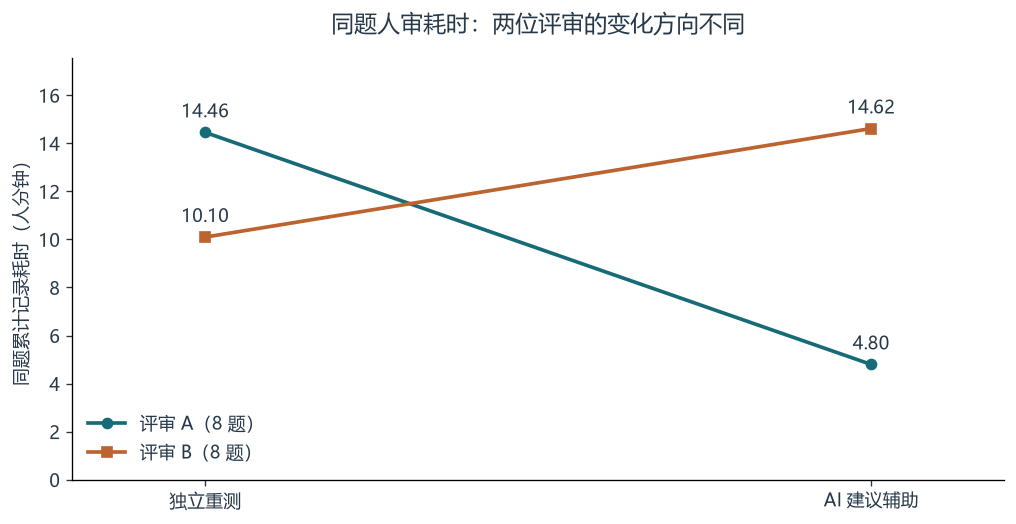

In [7]:
if final_summary is not None:
    human = final_summary["human"]
    timing = final_csv("human-role-timing.csv")
    stages = ["retest-v2", "guided-v3"]
    paired_timing = timing.loc[timing["round"].isin(stages)].pivot(index="role", columns="round", values="person_minutes").reindex(columns=stages)
    display(paired_timing.rename(columns={"retest-v2": "独立重测（人分钟）", "guided-v3": "AI辅助（人分钟）"}).round(2))
    display(pd.DataFrame([{"同题同角色配对": human["timed_pairs"], "前阶段人分钟": human["before_person_minutes"], "辅助阶段人分钟": human["after_person_minutes"], "耗时减少配对": human["faster_pairs"], "耗时增加配对": human["slower_pairs"]}]).round(2))
    fig, ax = plt.subplots(figsize=(8.6, 4.5))
    for role, color, marker in [("A", "#176B77", "o"), ("B", "#BC632F", "s")]:
        values = paired_timing.loc[role].to_numpy()
        ax.plot([0, 1], values, marker=marker, linewidth=2.2, color=color, label=f"评审 {role}（8 题）")
        for x, value in enumerate(values):
            ax.annotate(f"{value:.2f}", (x, value), xytext=(0, 9), textcoords="offset points", ha="center")
    ax.set_xticks([0, 1], ["独立重测", "AI 建议辅助"])
    ax.set(xlim=(-.2, 1.2), ylim=(0, paired_timing.to_numpy().max()*1.2), ylabel="同题累计记录耗时（人分钟）", title="同题人审耗时：两位评审的变化方向不同")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "final-human-role-timing", "同题8项、两角色共16对；时间包含停顿，固定顺序与共同推荐限制因果解释。", kind="real", sources=["results/final-analysis/human-role-timing.csv", "results/final-analysis/summary.json"], notebook="03_人审与校准.ipynb")
    plt.show()

累计耗时由 24.55 降至 19.41 人分钟，A 减少而 B 增加。13 对耗时减少、3 对增加。
同题重复、固定顺序、共同推荐和记录停顿均可能影响时间，因此这些观察不估计 AI 辅助的因果效率收益。

In [8]:
if final_summary is not None:
    human_agreement = []
    for stage in ["retest-v2", "guided-v3"]:
        row = human["rounds"][stage]
        numeric_equal = int(np.trace(np.asarray(row["matrix6"])))
        human_agreement.append({"阶段": stage, "同题分母": row["paired_items"], "完全一致（含共同弃权）": row["exact_including_abstention"], "共同弃权": row["exact_including_abstention"] - numeric_equal, "双方数字标签": row["both_labeled"], "六级κ": row["kappa6"], "三阶κ": row["kappa3"]})
    display(pd.DataFrame(human_agreement).round(3))

,阶段,同题分母,完全一致（含共同弃权）,共同弃权,双方数字标签,六级κ,三阶κ
0,retest-v2,8,4,0,7,0.344,0.323
1,guided-v3,8,6,2,6,0.556,1.000


完全一致由 4/8 变为 6/8，后者包含 2 道共同弃权；六级 κ 分别只用 7 道与 6 道双方数字标签题计算。
辅助阶段的采纳记录与独立盲审有不同测量条件，不能作为独立金标准来校准全部模型标签。